# Regresión Lineal Múltiple – Pronóstico del Precio de una Casa
**Objetivo:** Pronosticar el precio de una casa a partir de variables que la definen (habitaciones, baños, superficie, etc.)

In [1]:
# Carga de librerías y lectura del archivo
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

data_casas = pd.read_csv('kc_house_data.csv')
data_casas.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Variables independientes seleccionadas (X):

variables_X = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'waterfront', 'view', 'condition',
    'grade', 'sqft_basement', 'yr_built'
]

# Agregar columna de intercepto (columna de unos)
data_casas['Intercepto'] = 1

# Variable dependiente (Y): price
# Reordenar: Intercepto primero, luego variables, luego precio
cols_modelo = ['Intercepto'] + variables_X + ['price']
data_casas = data_casas[cols_modelo]

print(data_casas.shape)
data_casas.head()

(21613, 13)


,Intercepto,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,yr_built,price
0,1,3,1.00,1180,5650,1.0,0,0,3,7,0,1955,221900.0
1,1,3,2.25,2570,7242,2.0,0,0,3,7,400,1951,538000.0
2,1,2,1.00,770,10000,1.0,0,0,3,6,0,1933,180000.0
3,1,4,3.00,1960,5000,1.0,0,0,5,7,910,1965,604000.0
4,1,3,2.00,1680,8080,1.0,0,0,3,8,0,1987,510000.0


In [4]:
# Matrices X (variables independientes), Y (variable objetivo)
Xdata = data_casas[['Intercepto'] + variables_X].values
Ydata = data_casas[['price']].values

In [5]:
from sklearn.model_selection import train_test_split
# División en conjuntos de entrenamiento (70 %) y prueba (30 %)
X_train, X_test, Y_train, Y_test = train_test_split(
    Xdata, Ydata, test_size=0.3, random_state=1
)

In [6]:
# Asignación de matrices de entrenamiento
X = X_train
Y = Y_train

In [7]:
# Renglones
X.shape[0]

15129

In [8]:
# Columnas
X.shape[1]

12

In [9]:
# Formato numérico
np.set_printoptions(formatter={'float_kind': '{:f}'.format})

In [10]:
# Cálculo de X'X  (producto de X transpuesta por X)
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[15129.000000, 50963.000000, 32017.000000, 31442387.000000,
        230231424.000000, 22665.000000, 116.000000, 3505.000000,
        51592.000000, 115894.000000, 4424997.000000, 29820815.000000],
       [50963.000000, 184941.000000, 113274.250000, 113202849.000000,
        792701993.000000, 77591.000000, 372.000000, 12596.000000,
        174087.000000, 396101.000000, 16753940.000000, 100513486.000000],
       [32017.000000, 113274.250000, 76568.375000, 74367338.750000,
        529228587.750000, 51082.750000, 306.000000, 9001.500000,
        108207.500000, 254161.750000, 10796334.000000, 63280042.500000],
       [31442387.000000, 113202849.000000, 74367338.750000,
        77688746971.000000, 575423643809.000000, 49691571.000000,
        358581.000000, 10127227.000000, 106683065.000000,
        253007293.000000, 11781400252.000000, 62104027960.000000],
       [230231424.000000, 792701993.000000, 529228587.750000,
        575423643809.000000, 31855025051772.000000, 342386937.500000

In [11]:
# Cálculo  (inversa de X'X)
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[0.518813, -0.000692, 0.004508, -0.000000, 0.000000, 0.001804,
        -0.000620, -0.000945, -0.003281, 0.000730, -0.000002, -0.000264],
       [-0.000692, 0.000122, -0.000040, -0.000000, 0.000000, 0.000010,
        0.000060, 0.000010, -0.000008, 0.000021, 0.000000, 0.000000],
       [0.004508, -0.000040, 0.000366, -0.000000, 0.000000, -0.000116,
        -0.000007, -0.000003, -0.000010, -0.000020, -0.000000, -0.000002],
       [-0.000000, -0.000000, -0.000000, 0.000000, -0.000000, -0.000000,
        -0.000000, -0.000000, 0.000000, -0.000000, -0.000000, 0.000000],
       [0.000000, 0.000000, 0.000000, -0.000000, 0.000000, 0.000000,
        0.000000, -0.000000, -0.000000, 0.000000, 0.000000, -0.000000],
       [0.001804, 0.000010, -0.000116, -0.000000, 0.000000, 0.000426,
        -0.000030, -0.000004, 0.000025, -0.000023, 0.000000, -0.000001],
       [-0.000620, 0.000060, -0.000007, -0.000000, 0.000000, -0.000030,
        0.010454, -0.000493, -0.000019, 0.000045, 0.000000, 0.00000

In [12]:
# Cálculo de X'Y  (producto de X transpuesta por Y)
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[8134792844.000000],
       [28921660282.000000],
       [19344041227.500000],
       [20285899254544.000000],
       [142407378785985.000000],
       [12932928855.500000],
       [186574092.000000],
       [3471948304.000000],
       [27861195467.000000],
       [66500354540.000000],
       [3124774008563.000000],
       [16042657850839.000000]])

In [13]:
# Coeficientes Beta
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[6214667.156785],
       [-34440.262582],
       [44223.363711],
       [162.817877],
       [-0.238041],
       [27629.448288],
       [563509.935895],
       [43344.835367],
       [16611.910755],
       [123673.209314],
       [0.348496],
       [-3576.269932]])

In [14]:
nombres = ['Intercepto'] + variables_X
print("Ecuación del modelo:")
print(f"  price = ", end="")
for i, (nombre, beta) in enumerate(zip(nombres, betas.flatten())):
    if i == 0:
        print(f"{beta:.4f}", end="")
    else:
        signo = "+" if beta >= 0 else "-"
        print(f" {signo} {abs(beta):.4f}·{nombre}", end="")
print()

Ecuación del modelo:
  price = 6214667.1568 - 34440.2626·bedrooms + 44223.3637·bathrooms + 162.8179·sqft_living - 0.2380·sqft_lot + 27629.4483·floors + 563509.9359·waterfront + 43344.8354·view + 16611.9108·condition + 123673.2093·grade + 0.3485·sqft_basement - 3576.2699·yr_built


In [15]:
# Cálculo de TSS (Suma Total de Cuadrados)
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y) * (Y.mean()**2)
TSS

array([[1900668073054776.000000]])

In [16]:
# Cálculo de ESS (Suma Explicada por el Modelo)
ESS = np.matmul(
    np.matmul(np.matrix.transpose(betas), np.matrix.transpose(X)),
    np.matmul(X, betas)
) - len(Y) * (Y.mean()**2)
ESS

array([[1237698029176246.000000]])

In [17]:
# Cálculo de RSS (Residuales al Cuadrado = TSS - ESS)
RSS = TSS - ESS
RSS

array([[662970043878530.000000]])

In [18]:
# Cálculo del Coeficiente de Determinación R²  (bondad del ajuste)
RSq = 1 - RSS / TSS
RSq

array([[0.651191]])

In [19]:
# Cálculo del Coeficiente de Determinación R² Ajustada
RSqAj = 1 - (RSS / (X.shape[0] - X.shape[1])) / (TSS / (X.shape[0] - 1))
RSqAj

array([[0.650937]])

In [20]:
# Reporte Automatizado de la Regresión (OLS – statsmodels)
import statsmodels.api as sm

regressor = sm.OLS(Y, X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     2566.
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:13:16   Log-Likelihood:            -2.0682e+05
No. Observations:               15129   AIC:                         4.137e+05
Df Residuals:                   15117   BIC:                         4.138e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.215e+06   1.51e+05     41.200      0.0

In [21]:
# Aplicación del modelo sobre la base de prueba
Y_pred = np.matmul(X_test, betas)
Y_pred

array([[716824.811303],
       [315524.029720],
       [849224.220486],
       ...,
       [361261.872679],
       [2122509.209855],
       [881901.129051]], shape=(6484, 1))

In [22]:
# Cálculo de residuales en la base de prueba
Resid = Y_test - Y_pred
Resid

array([[-257824.811303],
       [129475.970280],
       [207775.779514],
       ...,
       [-131261.872679],
       [-442509.209855],
       [-588901.129051]], shape=(6484, 1))

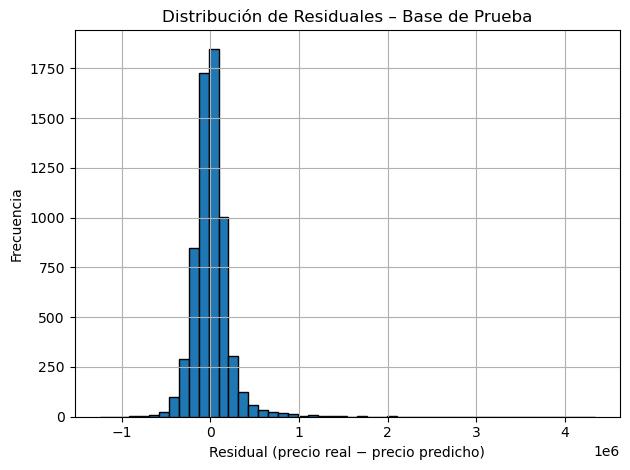

In [23]:
# Gráfico del histograma de residuales (base de prueba)
import matplotlib.pyplot as plt

df_resid = pd.DataFrame(Resid, columns=['Residuales'])
df_resid.hist(bins=50, edgecolor='black')
plt.title('Distribución de Residuales – Base de Prueba')
plt.xlabel('Residual (precio real − precio predicho)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [25]:
# Cálculo del Score R² sobre la base de PRUEBA (evaluación out-of-sample)
from sklearn.metrics import r2_score

r2_prueba = r2_score(Y_test, Y_pred)
print(f"R² en entrenamiento (matricial): {float(RSq):.4f}")
print(f"R² en prueba        (sklearn)  : {r2_prueba:.4f}")

R² en entrenamiento (matricial): 0.6512
R² en prueba        (sklearn)  : 0.6526
